In [1]:
import numpy as np
import torch, torch.nn as nn
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import model_bs as mdl
import data_utils as du
import dataset as ds

token_to_idx, idx_to_token = du.load_or_create_vocabulary(csv_paths=[], cache_path="vocab.json",test_smiles=None)

assert token_to_idx["<PAD>"] == 0
assert token_to_idx["<SOS>"] == 2
assert token_to_idx["<EOS>"] == 3

model = mdl.LSTM_VAE_Trans(
        vocab_size=len(token_to_idx),
        d_model=256,
        latent_dim=64,
        pad_idx=0,
        sos_idx=2,
        eos_idx=3,
        enc_layers=7,
        dec_layers=7,
        nhead=8,
        dropout=0.05,
        max_len=160,
        dim_feedforward=1024)
model.load_state_dict(torch.load("checkpoints/best_model.pth", map_location="cpu"))

# unwrap DataParallel if needed, and get device
m = model.module if isinstance(model, nn.DataParallel) else model
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
model.to(device)
m = model  # (no DP wrapping here)
m.eval()

[vocab] loaded cached vocabulary from vocab.json (69 tokens)


LSTM_VAE_Trans(
  (encoder): EncoderBiLSTM(
    (emb): Embedding(69, 256, padding_idx=0)
    (emb_ln): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    (emb_do): Dropout(p=0.1, inplace=False)
    (lstm): LSTM(256, 128, num_layers=7, batch_first=True, dropout=0.05, bidirectional=True)
    (out_do): Dropout(p=0.05, inplace=False)
    (seq_ln): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    (pool_ln): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
  )
  (to_mu): Linear(in_features=256, out_features=64, bias=True)
  (to_logvar): Linear(in_features=256, out_features=64, bias=True)
  (latent_to_token): Sequential(
    (0): Linear(in_features=64, out_features=256, bias=True)
    (1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
  )
  (decoder): TransformerDecoder(
    (emb): Embedding(69, 256, padding_idx=0)
    (emb_ln): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    (pe): PositionalEncoding(
      (dropout): Dropout(p=0.05, inplace=False)
    )

In [2]:
# Example configuration dictionary
cfg = {"test_files": ["Data/union_586k.csv"], "seq_length": 160, "latent_dim": 64}
smiles = du.load_smiles_list([cfg["test_files"][0]], n_samples=586000, shuffle=False)
test_ds = ds.SMILESDataset(smiles, seq_length=cfg["seq_length"], token_to_idx=token_to_idx,augmentor=None, augment_train=False)
test_dl = DataLoader(test_ds, batch_size=256, shuffle=False, num_workers=4, pin_memory=device.type == "cuda")

In [3]:
latents = []
with torch.no_grad():
    for inp, tgt in test_dl:                 # dataset returns (seq, seq)
        inp, tgt = inp.to(device), tgt.to(device)
        # forward with TF returns (logits, mu, logvar)
        _, mu, _ = m(inp, tgt=tgt, teacher_forcing=True)
        latents.append(mu.cpu().numpy())

Z = np.concatenate(latents, axis=0)          # [N, latent_dim]
print("Latents shape:", Z.shape)

Latents shape: (586000, 64)


In [4]:
from rdkit import Chem
from rdkit.Chem import Descriptors, rdMolDescriptors, QED
import networkx as nx
import numpy as np
import pandas as pd


def longest_conjugated_path(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return np.nan

    graph = nx.Graph()
    graph.add_nodes_from(atom.GetIdx() for atom in mol.GetAtoms())
    graph.add_edges_from( (bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()) for bond in mol.GetBonds() if bond.GetIsConjugated() or bond.GetIsAromatic() )
    if graph.number_of_edges() == 0:
        return 0

    longest_path = 0
    for component in nx.connected_components(graph):
        lengths = dict(nx.all_pairs_shortest_path_length(graph.subgraph(component)))
        longest_path = max(longest_path, max(max(d.values()) for d in lengths.values()) + 1)
    return longest_path


def aromatic_surface_fraction(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return np.nan
    heavy_atoms = [atom for atom in mol.GetAtoms() if atom.GetAtomicNum() > 1]
    if not heavy_atoms:
        return np.nan
    return sum(atom.GetIsAromatic() for atom in heavy_atoms) / len(heavy_atoms)


def props_from_smiles(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    return {
        "MW": Descriptors.MolWt(mol),
        "LogP": Descriptors.MolLogP(mol),
        "TPSA": rdMolDescriptors.CalcTPSA(mol),
        "HBA": rdMolDescriptors.CalcNumHBA(mol),
        "HBD": rdMolDescriptors.CalcNumHBD(mol),
        "AromRings": rdMolDescriptors.CalcNumAromaticRings(mol),
        "RotBonds": rdMolDescriptors.CalcNumRotatableBonds(mol),
        "HeavyAtoms": mol.GetNumHeavyAtoms(),
        "Fsp3": rdMolDescriptors.CalcFractionCSP3(mol),
        "QED": QED.qed(mol),
    }


prop_df = pd.DataFrame([props_from_smiles(s) for s in smiles])


In [5]:
valid_mask = prop_df.notna().all(axis=1).values
Z_ok = Z[valid_mask]
smiles_ok = [s for s, keep in zip(smiles, valid_mask) if keep]
props_ok = prop_df.loc[valid_mask].reset_index(drop=True)
props_ok["ConjugLength"] = np.array([longest_conjugated_path(s) for s in smiles_ok], dtype=np.float32)
props_ok["AroSurfFrac"] = np.array([aromatic_surface_fraction(s) for s in smiles_ok], dtype=np.float32)
y_conj = props_ok["ConjugLength"].values
print("Kept:", len(smiles_ok), "of", len(smiles))


Kept: 586000 of 586000


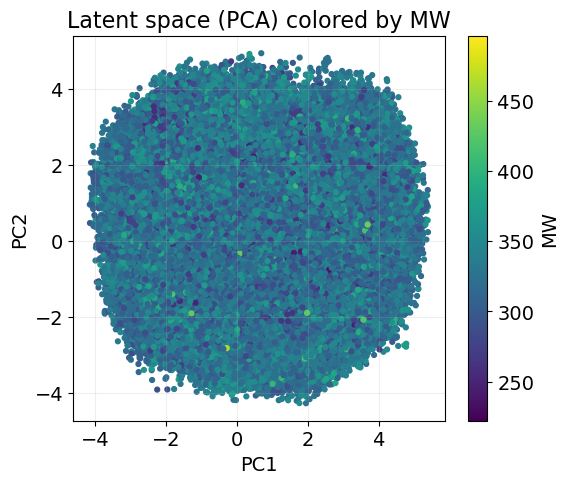

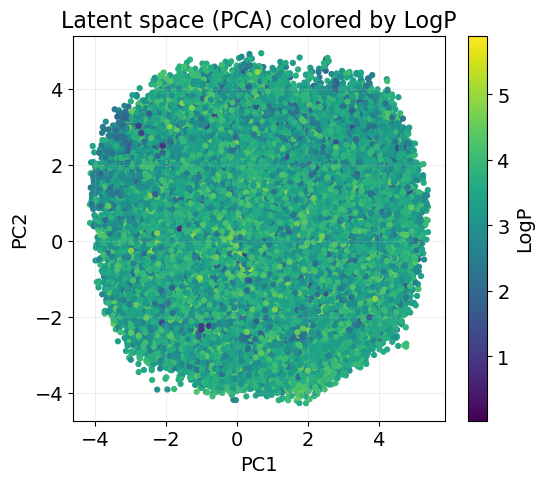

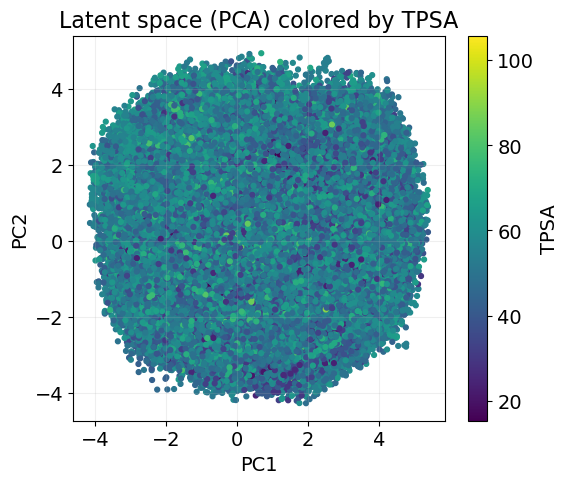

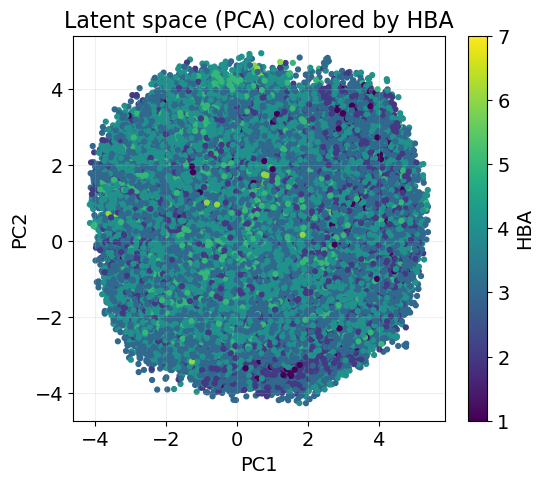

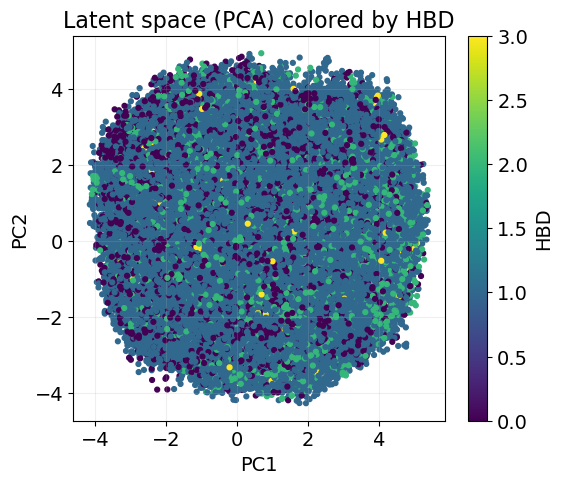

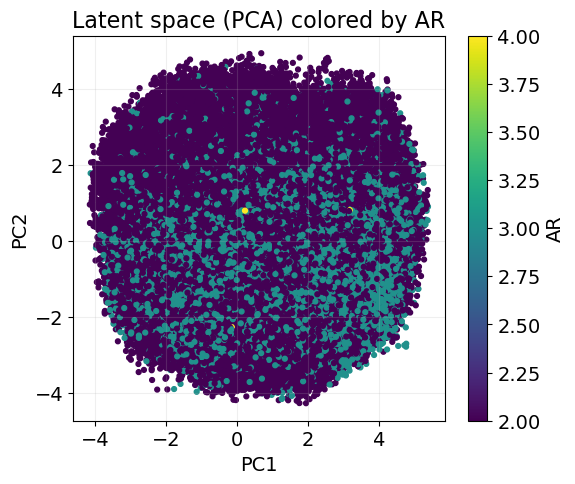

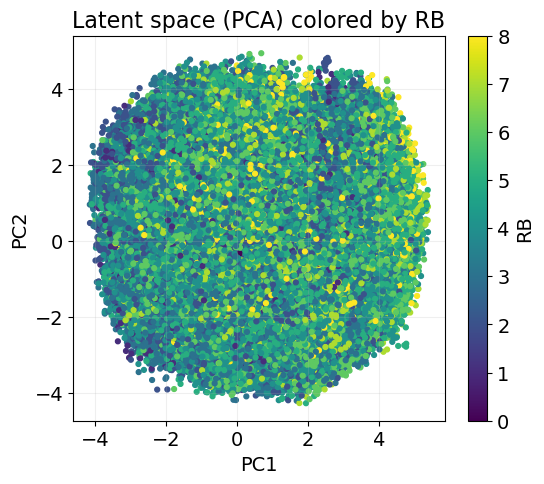

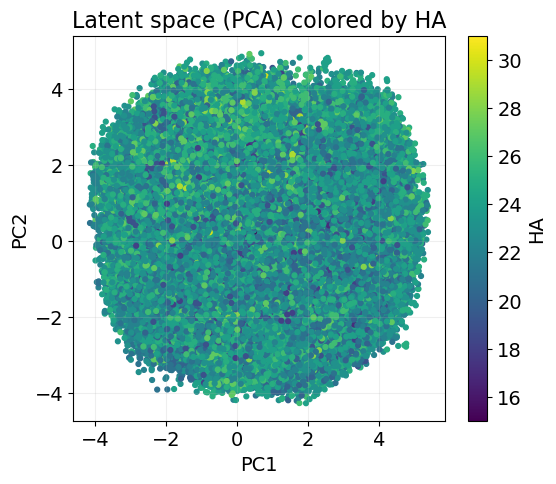

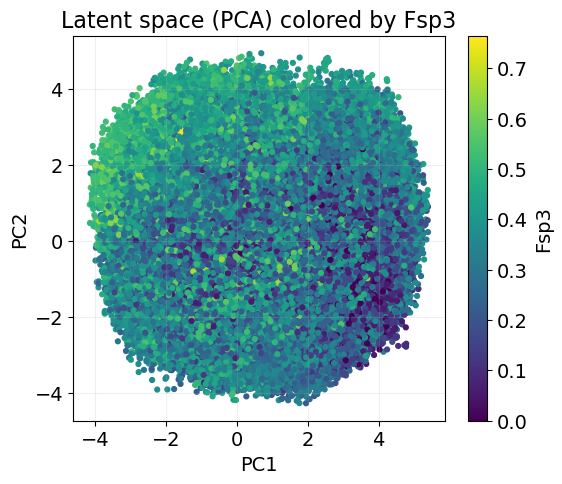

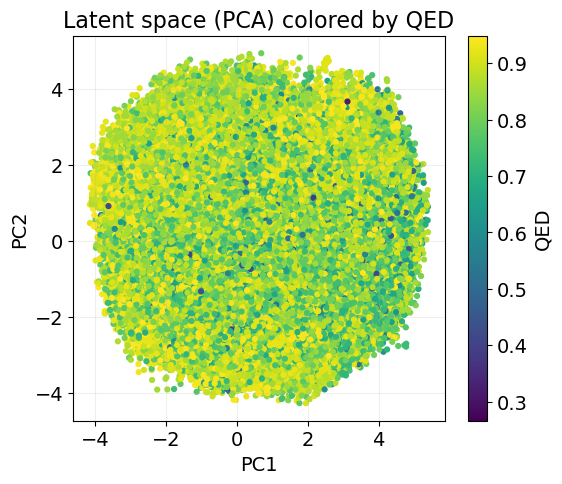

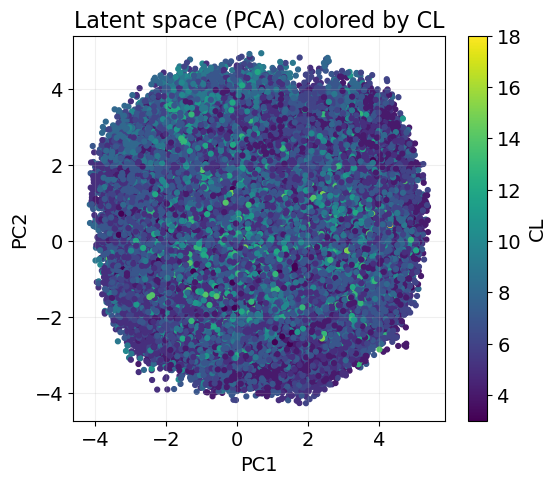

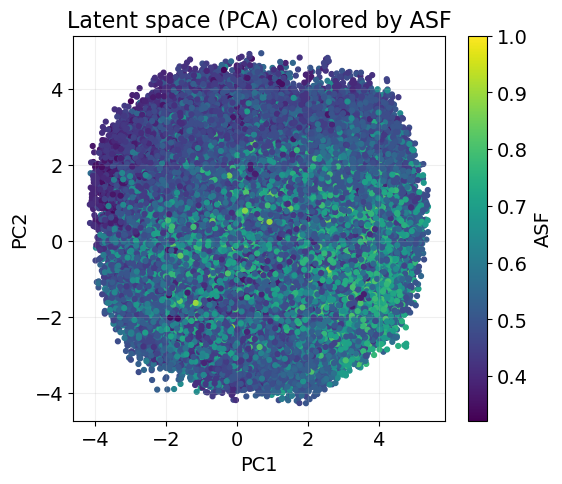

In [6]:
from sklearn.decomposition import PCA

XY = PCA(n_components=2).fit_transform(Z_ok)
PROPERTY_LABELS = {
    "MW": "MW",
    "LogP": "LogP",
    "TPSA": "TPSA",
    "HBA": "HBA",
    "HBD": "HBD",
    "AromRings": "AR",
    "RotBonds": "RB",
    "HeavyAtoms": "HA",
    "Fsp3": "Fsp3",
    "QED": "QED",
    "ConjugationLength": "CL",
    "ConjugLength": "CL",
    "ConLength": "CL",
    "AromaticSurfaceFraction": "ASF",
    "AroSurfFrac": "ASF",
    "AromSurfFrac": "ASF",
}
PLOT_PROPS = ["MW", "LogP", "TPSA", "HBA", "HBD", "AromRings", "RotBonds", "HeavyAtoms", "Fsp3", "QED", "ConjugLength", "AroSurfFrac"]


def property_label(prop_name):
    return PROPERTY_LABELS.get(prop_name, prop_name)


def scatter_by(colname):
    display_name = property_label(colname)
    plt.figure(figsize=(6, 5))
    sc = plt.scatter(XY[:, 0], XY[:, 1], c=props_ok[colname].values, s=12, cmap="viridis")
    cbar = plt.colorbar(sc, label=display_name)
    cbar.ax.tick_params(labelsize=14)
    cbar.set_label(display_name, fontsize=14)
    plt.title(f"Latent space (PCA) colored by {display_name}", fontsize=16)
    plt.xlabel("PC1", fontsize=14)
    plt.ylabel("PC2", fontsize=14)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.grid(alpha=0.2)
    plt.show()


for col in PLOT_PROPS:
    scatter_by(col)


In [7]:
# PROPS = ["MW", "LogP", "TPSA", "HBA", "HBD", "AromRings", "RotBonds", "HeavyAtoms", "Fsp3", "QED", "ConjugationLength", "AromaticSurfaceFraction"]
# LATENT_DIM = Z_ok.shape[1]
# CKPT_PATH = "checkpoints/property_head_best.pt"

# import numpy as np
# import pandas as pd
# import torch
# import torch.nn as nn
# import torch.optim as optim
# from sklearn.linear_model import Ridge
# from sklearn.metrics import mean_absolute_error, r2_score
# from sklearn.model_selection import train_test_split

# property_targets = props_ok.rename(columns={
#     "ConjugLength": "ConjugationLength",
#     "AroSurfFrac": "AromaticSurfaceFraction",
# })[PROPS]
# X_tr, X_va, target_tr, target_va = train_test_split(
#     Z_ok, property_targets, test_size=0.2, random_state=0
# )

# X_mu = X_tr.mean(axis=0, keepdims=True)
# X_sd = X_tr.std(axis=0, keepdims=True) + 1e-8
# Xtr = (X_tr - X_mu) / X_sd
# Xva = (X_va - X_mu) / X_sd
# Xt = torch.tensor(Xtr, dtype=torch.float32, device=device)
# Xv = torch.tensor(Xva, dtype=torch.float32, device=device)


# class PropertyHead(nn.Module):
#     def __init__(self, in_dim, hidden1=128, hidden2=64, p_drop=0.1):
#         super().__init__()
#         self.net = nn.Sequential(
#             nn.Linear(in_dim, hidden1), nn.ReLU(), nn.Dropout(p_drop),
#             nn.Linear(hidden1, hidden2), nn.ReLU(), nn.Dropout(p_drop),
#             nn.Linear(hidden2, 1),
#         )

#     def forward(self, x):
#         return self.net(x)


# def train_single_property_head(prop_name, y_tr, y_va):
#     y_tr = y_tr.astype(np.float32).reshape(-1, 1)
#     y_va = y_va.astype(np.float32).reshape(-1, 1)
#     y_mu = y_tr.mean(axis=0, keepdims=True)
#     y_sd = y_tr.std(axis=0, keepdims=True) + 1e-8
#     Yt = torch.tensor((y_tr - y_mu) / y_sd, dtype=torch.float32, device=device)
#     Yv = torch.tensor((y_va - y_mu) / y_sd, dtype=torch.float32, device=device)

#     ridge = Ridge(alpha=1.0).fit(Xtr, y_tr.ravel())
#     ridge_pred = ridge.predict(Xva)

#     model = PropertyHead(LATENT_DIM).to(device)
#     opt = optim.AdamW(model.parameters(), lr=3e-3, weight_decay=2e-4)
#     loss_fn = nn.MSELoss()
#     best_val = float("inf")
#     best_state = None
#     epochs_no_improve = 0

#     for ep in range(1, EPOCHS + 1):
#         model.train()
#         opt.zero_grad()
#         loss_tr = loss_fn(model(Xt), Yt)
#         loss_tr.backward()
#         opt.step()

#         model.eval()
#         with torch.no_grad():
#             loss_va = loss_fn(model(Xv), Yv).item()

#         if loss_va < best_val - 1e-7:
#             best_val = loss_va
#             epochs_no_improve = 0
#             best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
#         else:
#             epochs_no_improve += 1

#         if ep % print_every == 0 or ep == 1:
#             print(f"{prop_name:24s} [{ep:04d}] train MSE: {loss_tr.item():.6f} | val MSE: {loss_va:.6f} | best: {best_val:.6f}")
#         if epochs_no_improve >= patience:
#             print(f"{prop_name:24s} [Early stop] epoch {ep}; best val MSE: {best_val:.6f}")
#             break

#     if best_state is not None:
#         model.load_state_dict(best_state)

#     model.eval()
#     with torch.no_grad():
#         mlp_pred = model(Xv).cpu().numpy() * y_sd + y_mu

#     return {
#         "property": prop_name,
#         "MAE_ridge": mean_absolute_error(y_va.ravel(), ridge_pred),
#         "R2_ridge": r2_score(y_va.ravel(), ridge_pred),
#         "MAE_mlp": mean_absolute_error(y_va.ravel(), mlp_pred.ravel()),
#         "R2_mlp": r2_score(y_va.ravel(), mlp_pred.ravel()),
#         "model_state": model.state_dict(),
#         "y_mu": torch.tensor(y_mu, dtype=torch.float32),
#         "y_sd": torch.tensor(y_sd, dtype=torch.float32),
#         "best_val_mse_stdspace": float(best_val),
#         "ridge_alpha": float(ridge.alpha),
#     }


# EPOCHS = 1000
# patience = 50
# print_every = 25
# results = []
# model_states = {}
# y_scalers = {}

# for prop_name in PROPS:
#     result = train_single_property_head(
#         prop_name,
#         target_tr[prop_name].values,
#         target_va[prop_name].values,
#     )
#     results.append({k: result[k] for k in ["property", "MAE_ridge", "R2_ridge", "MAE_mlp", "R2_mlp"]})
#     model_states[prop_name] = result["model_state"]
#     y_scalers[prop_name] = {
#         "y_mu": result["y_mu"],
#         "y_sd": result["y_sd"],
#         "best_val_mse_stdspace": result["best_val_mse_stdspace"],
#     }

# cmp = pd.DataFrame(results).sort_values("R2_mlp", ascending=False).reset_index(drop=True)
# display(cmp)
# print("Ridge averages -> MAE:", float(cmp["MAE_ridge"].mean()), "R2:", float(cmp["R2_ridge"].mean()))
# print("MLP averages -> MAE:", float(cmp["MAE_mlp"].mean()), "R2:", float(cmp["R2_mlp"].mean()))

# ckpt = {
#     "model_states": model_states,
#     "x_mu": torch.tensor(X_mu, dtype=torch.float32),
#     "x_sd": torch.tensor(X_sd, dtype=torch.float32),
#     "y_scalers": y_scalers,
#     "props": PROPS,
#     "latent_dim": LATENT_DIM,
#     "arch": {"hidden1": 128, "hidden2": 64, "p_drop": 0.1, "out_dim": 1},
#     "val_metrics": cmp.to_dict(orient="records"),
#     "ridge_alpha": 1.0,
# }
# torch.save(ckpt, CKPT_PATH)
# print(f"Saved independent MLP heads, scalers, and metrics to:\n  {CKPT_PATH}")

PROPS = ["MW", "LogP", "TPSA", "HBA", "HBD", "AromRings", "RotBonds", "HeavyAtoms", "Fsp3", "QED", "ConjugationLength", "AromaticSurfaceFraction"]
LATENT_DIM = Z_ok.shape[1]
CKPT_PATH = "checkpoints/property_head_best.pt"


class PropertyHead(nn.Module):
    def __init__(self, in_dim, hidden1=128, hidden2=64, p_drop=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden1), nn.ReLU(), nn.Dropout(p_drop),
            nn.Linear(hidden1, hidden2), nn.ReLU(), nn.Dropout(p_drop),
            nn.Linear(hidden2, 1),
        )

    def forward(self, x):
        return self.net(x)


property_ckpt = torch.load(CKPT_PATH, map_location="cpu")
saved_props = property_ckpt["props"]
arch = property_ckpt.get("arch", {"hidden1": 128, "hidden2": 64, "p_drop": 0.1})
ckpt_latent_dim = int(property_ckpt.get("latent_dim", LATENT_DIM))
if ckpt_latent_dim != LATENT_DIM:
    raise ValueError(f"Property head latent_dim={ckpt_latent_dim}, but Z_ok has {LATENT_DIM} columns")

property_heads = {}
for prop_name in saved_props:
    head = PropertyHead(
        LATENT_DIM,
        hidden1=arch.get("hidden1", 128),
        hidden2=arch.get("hidden2", 64),
        p_drop=arch.get("p_drop", 0.1),
    ).to(device)
    head.load_state_dict(property_ckpt["model_states"][prop_name])
    head.eval()
    property_heads[prop_name] = head

x_mu = property_ckpt["x_mu"].to(device).float()
x_sd = property_ckpt["x_sd"].to(device).float()
y_scalers = property_ckpt["y_scalers"]


@torch.no_grad()
def predict_saved_properties(Z_values, props=None, batch_size=4096):
    props = list(saved_props if props is None else props)
    missing = [prop for prop in props if prop not in property_heads]
    if missing:
        raise KeyError(f"Properties not found in saved checkpoint: {missing}")

    if isinstance(Z_values, np.ndarray):
        Z_tensor = torch.from_numpy(Z_values).float()
    else:
        Z_tensor = torch.as_tensor(Z_values, dtype=torch.float32)

    predictions = {prop: [] for prop in props}
    for start in range(0, Z_tensor.shape[0], batch_size):
        xb = Z_tensor[start:start + batch_size].to(device)
        xb = (xb - x_mu) / x_sd
        for prop in props:
            scaler = y_scalers[prop]
            y_mu = scaler["y_mu"].to(device).float()
            y_sd = scaler["y_sd"].to(device).float()
            y_pred = property_heads[prop](xb) * y_sd + y_mu
            predictions[prop].append(y_pred.detach().cpu().numpy().ravel())

    return pd.DataFrame({prop: np.concatenate(values) for prop, values in predictions.items()})


print(f"Loaded saved property heads from {CKPT_PATH}: {len(property_heads)} properties")

Loaded saved property heads from checkpoints/property_head_best.pt: 12 properties


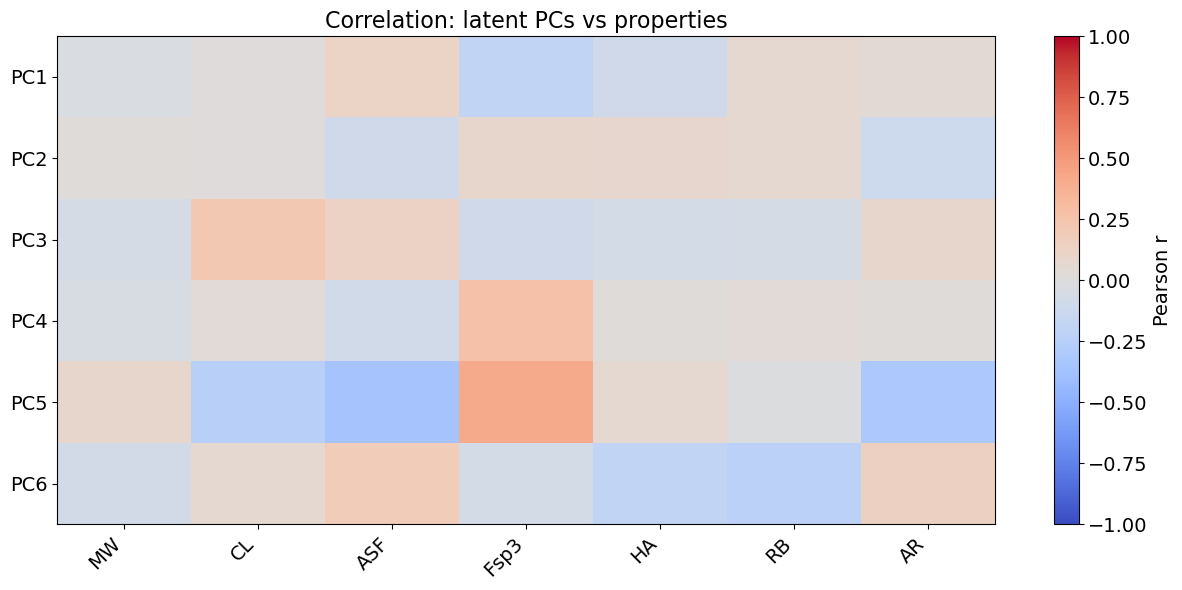

In [8]:
PCA_HEATMAP_PROPS = ["MW", "ConjugLength", "AroSurfFrac", "Fsp3", "HeavyAtoms", "RotBonds", "AromRings"]
missing_props = [col for col in PCA_HEATMAP_PROPS if col not in props_ok.columns]
if missing_props:
    raise KeyError(f"Missing PCA heatmap properties: {missing_props}")

pca_full = PCA(n_components=min(20, Z_ok.shape[1]))
Z_pc = pca_full.fit_transform(Z_ok)[:, :6]
pc_df = pd.DataFrame(Z_pc, columns=[f"PC{i + 1}" for i in range(Z_pc.shape[1])])
pc_prop_corr = pd.concat([pc_df, props_ok[PCA_HEATMAP_PROPS]], axis=1).corr().loc[pc_df.columns, PCA_HEATMAP_PROPS]

plt.figure(figsize=(1.5 * len(PCA_HEATMAP_PROPS) + 2, 6))
im = plt.imshow(pc_prop_corr.values, aspect="auto", cmap="coolwarm", vmin=-1, vmax=1)
cbar = plt.colorbar(im)
cbar.ax.tick_params(labelsize=14)
cbar.set_label("Pearson r", fontsize=14)
plt.yticks(range(len(pc_df.columns)), pc_df.columns, fontsize=14)
plt.xticks(range(len(PCA_HEATMAP_PROPS)), [property_label(col) for col in PCA_HEATMAP_PROPS], rotation=45, ha="right", fontsize=14)
plt.title("Correlation: latent PCs vs properties", fontsize=16)
plt.tight_layout()
plt.savefig("pca_property_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()


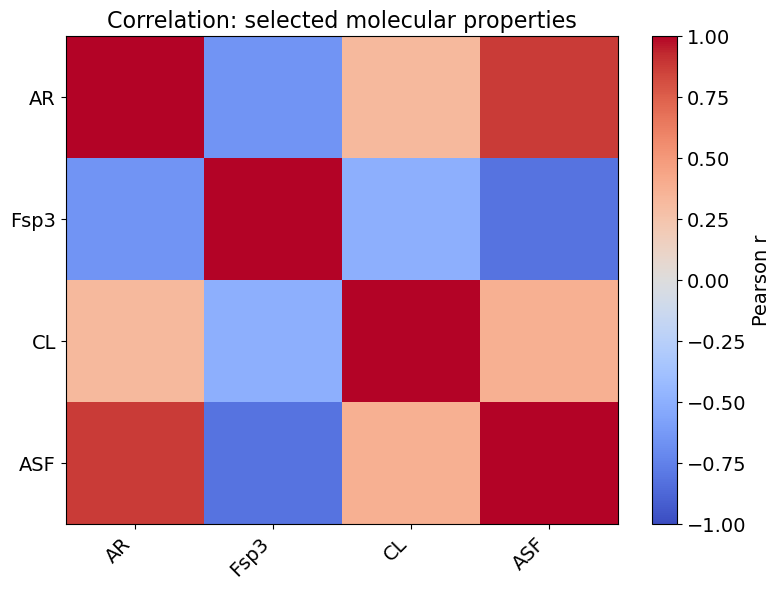

In [9]:
CORR_PROPS = ["AromRings", "Fsp3", "ConjugLength", "AroSurfFrac"]
prop_corr = props_ok[CORR_PROPS].corr()

plt.figure(figsize=(1.5 * len(CORR_PROPS) + 2, 6))
im = plt.imshow(prop_corr.values, aspect="auto", cmap="coolwarm", vmin=-1, vmax=1)
cbar = plt.colorbar(im)
cbar.ax.tick_params(labelsize=14)
cbar.set_label("Pearson r", fontsize=14)
plt.yticks(range(len(CORR_PROPS)), [property_label(col) for col in CORR_PROPS], fontsize=14)
plt.xticks(range(len(CORR_PROPS)), [property_label(col) for col in CORR_PROPS], rotation=45, ha="right", fontsize=14)
plt.title("Correlation: selected molecular properties", fontsize=16)
plt.tight_layout()
plt.savefig("property_property_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()


Explained variance PC1: 0.06997058775362877
Explained variance PC2: 0.05298416090911935
Explained variance PC1+PC2: 0.12295474866274812
Explained variance first 10 PCs: 0.417709220421302


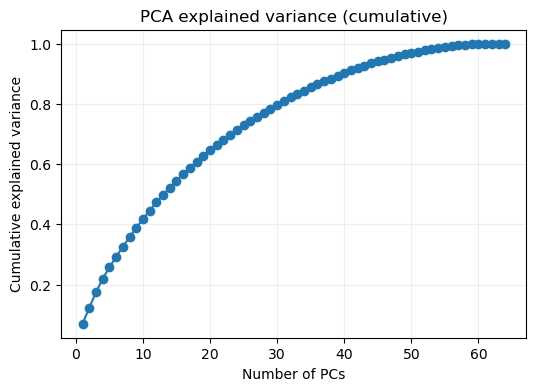

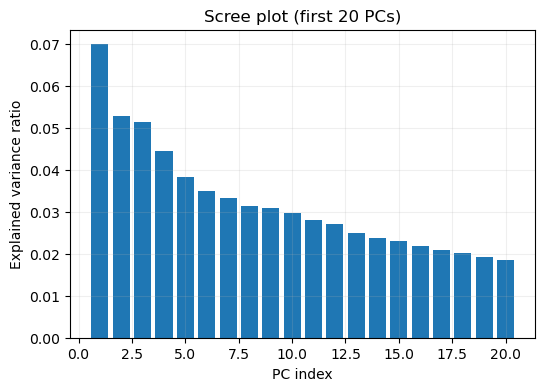

In [10]:
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

pca_full = PCA(n_components=min(64, Z_ok.shape[1]))
pca_full.fit(Z_ok)

evr = pca_full.explained_variance_ratio_
cum = np.cumsum(evr)

print("Explained variance PC1:", evr[0])
print("Explained variance PC2:", evr[1])
print("Explained variance PC1+PC2:", evr[0] + evr[1])
print("Explained variance first 10 PCs:", cum[9])

plt.figure(figsize=(6,4))
plt.plot(np.arange(1, len(evr)+1), cum, marker="o")
plt.xlabel("Number of PCs")
plt.ylabel("Cumulative explained variance")
plt.title("PCA explained variance (cumulative)")
plt.grid(alpha=0.2)
plt.show()

plt.figure(figsize=(6,4))
plt.bar(np.arange(1, 21), evr[:20])
plt.xlabel("PC index")
plt.ylabel("Explained variance ratio")
plt.title("Scree plot (first 20 PCs)")
plt.grid(alpha=0.2)
plt.show()

In [11]:
import torch
import numpy as np

@torch.no_grad()
def decode_from_z_greedy(m, z, max_len=160):
    """
    Greedy decode SMILES from a given latent vector z.
    z: (latent_dim,) or (B, latent_dim) numpy array or torch tensor
    returns: LongTensor [B, T] token ids (NO <SOS>, stops at <EOS> if produced)
    """
    m.eval()
    device = next(m.parameters()).device

    if isinstance(z, np.ndarray):
        z = torch.from_numpy(z)
    z = z.to(device).float()
    if z.dim() == 1:
        z = z.unsqueeze(0)

    # Build transformer "memory" from z exactly like training
    z_tok = m.latent_to_token(z).unsqueeze(1)  # [B, 1, d_model]
    mem_pad = torch.zeros(z_tok.size(0), 1, dtype=torch.bool, device=device)

    B = z_tok.size(0)
    ys = torch.full((B, 1), m.sos_idx, dtype=torch.long, device=device)

    out = []
    for _ in range(max_len):
        logits = m.decoder(ys, z_tok, mem_pad)              # [B, t, V]
        nxt = logits[:, -1].argmax(dim=-1, keepdim=True)    # [B, 1]
        ys = torch.cat([ys, nxt], dim=1)
        out.append(nxt)
        if (nxt == m.eos_idx).all():
            break

    gen = torch.cat(out, dim=1) if out else ys[:, 1:]
    return gen  # [B, T], tokens without <SOS>


def token_ids_to_smiles(token_ids, idx_to_token, eos_idx, pad_idx, sos_idx):
    """
    token_ids: list[int] OR 1D torch tensor of token ids (no <SOS> expected, but safe)
    """
    if isinstance(token_ids, torch.Tensor):
        token_ids = token_ids.detach().cpu().tolist()

    toks = []
    for i in token_ids:
        if i == eos_idx:
            break
        if i in (pad_idx, sos_idx):
            continue
        toks.append(idx_to_token[i])
    return "".join(toks)

Anchor SMILES: COc1ccc(C)cc1[C@H](C)[NH2+]Cc1cnn(-c2ccccc2)c1
Anchor CL = 7
Decoded SMILES (first 5): ['COc1ccc([C@H](C)C[C@H](C)C[NH2+]Cn1cnc(CO)cc1', 'COc1ccc(C)[C@H](C)C[C@H](CC)Cn1cnccc1)C', 'COc1ccc(C)[C@H](C)C[C@H](CC)Cn1cnccc1)C', 'COc1ccc(C)[C@H](C)C[C@H](CC)Cn1cnccc1)C', 'COc1ccc(C)[C@H](C)C[C@H](CC)Cn1cnccc1)C']


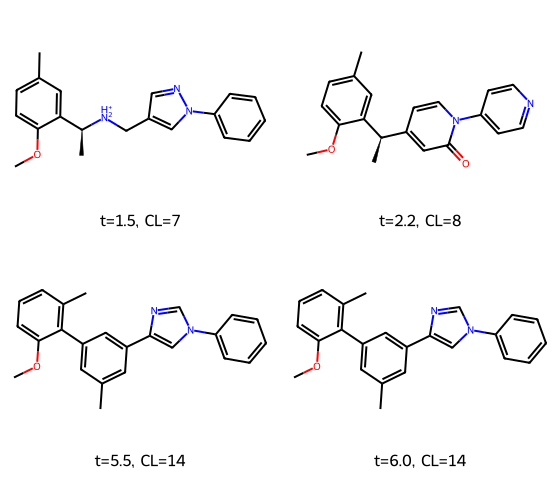

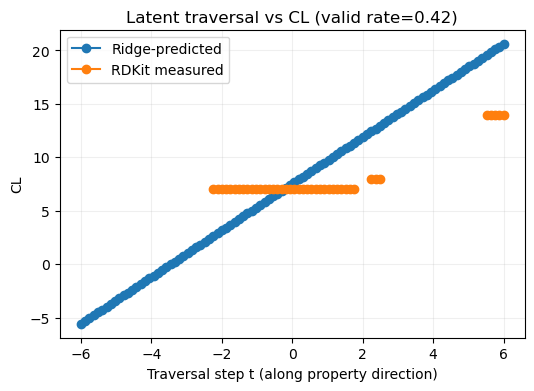

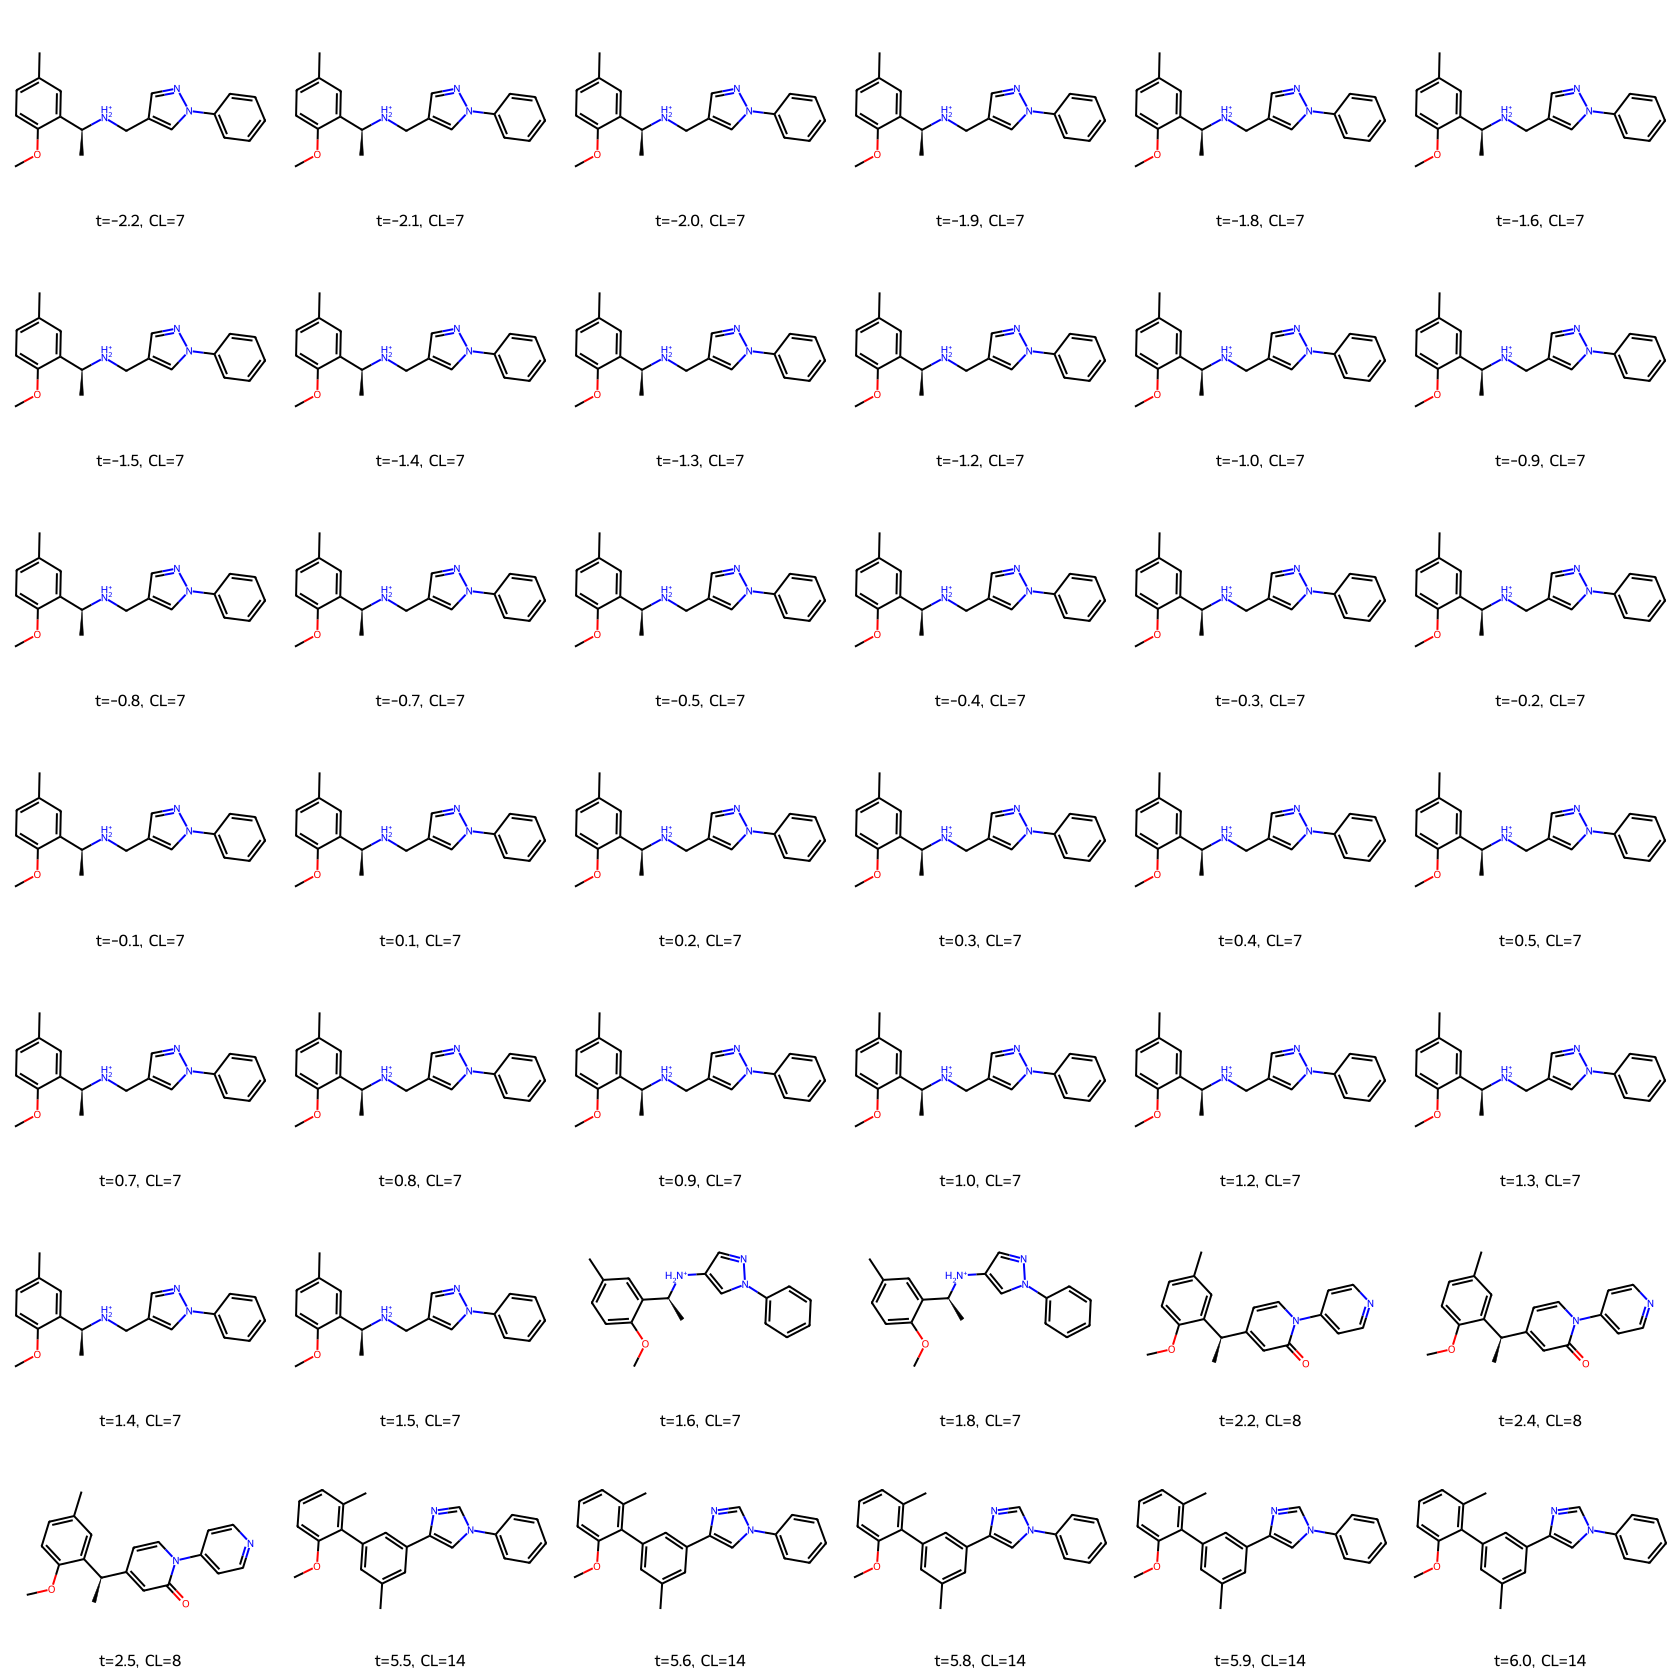

In [19]:
from sklearn.linear_model import Ridge
import matplotlib.pyplot as plt
from rdkit.Chem import Draw

TRAVERSAL_SOURCES = {"ConLength": ["ConjugLength", "ConjugationLength"], "AromSurfFrac": ["AroSurfFrac", "AromaticSurfaceFraction"], "MW": ["MW"]}


def latent_property_direction(Z, y, alpha=1.0):
    Zmu = Z.mean(0, keepdims=True)
    Zsd = Z.std(0, keepdims=True) + 1e-8
    Zs = (Z - Zmu) / Zsd
    reg = Ridge(alpha=alpha).fit(Zs, y)
    w = reg.coef_.astype(np.float32)
    return w / (np.linalg.norm(w) + 1e-8), Zmu, Zsd, reg


def measure_traversal_property(smiles, prop_name):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return np.nan
    if prop_name == "ConLength":
        return longest_conjugated_path(smiles)
    if prop_name == "AromSurfFrac":
        return aromatic_surface_fraction(smiles)
    if prop_name == "MW":
        return Descriptors.MolWt(mol)
    raise ValueError(f"Unsupported traversal property: {prop_name}")


def ensure_traversal_property(prop_name):
    if prop_name in props_ok.columns:
        return
    source_col = next((col for col in TRAVERSAL_SOURCES[prop_name] if col in props_ok.columns), None)
    if source_col is not None:
        props_ok[prop_name] = props_ok[source_col].values
    else:
        props_ok[prop_name] = np.array([measure_traversal_property(s, prop_name) for s in smiles_ok], dtype=np.float32)


def format_property_value(label, value):
    if not np.isfinite(value):
        return "nan"
    if label in {"HBA", "HBD", "AR", "RB", "HA", "CL"}:
        return f"{value:.0f}"
    return f"{value:.3f}"


def run_latent_traversal(prop_name, ts=None, plot=True):
    ensure_traversal_property(prop_name)
    label = property_label(prop_name)
    y = props_ok[prop_name].values.astype(np.float32)
    w, Zmu, Zsd, reg = latent_property_direction(Z_ok, y)
    mid_idx = int(np.argsort(y)[len(y) // 2])
    z0 = Z_ok[mid_idx].copy()
    ts = np.linspace(-6.0, 6.0, 100) if ts is None else np.asarray(ts, dtype=np.float32)

    decoded, preds, measured = [], [], []
    z0s = (z0 - Zmu.ravel()) / Zsd.ravel()
    for t in ts:
        z_new = (z0s + t * w) * Zsd.ravel() + Zmu.ravel()
        tok = decode_from_z_greedy(m, z_new, max_len=cfg["seq_length"])[0]
        smi = token_ids_to_smiles(tok, idx_to_token, eos_idx=token_to_idx["<EOS>"], pad_idx=token_to_idx["<PAD>"], sos_idx=token_to_idx["<SOS>"])
        decoded.append(smi)
        preds.append(float(reg.predict((z_new[None, :] - Zmu) / Zsd)[0]))
        measured.append(measure_traversal_property(smi, prop_name))

    result = {"ts": ts, "decoded": decoded, "preds": np.asarray(preds), "measured": np.asarray(measured, dtype=np.float32)}
    print("Anchor SMILES:", smiles_ok[mid_idx])
    print("Anchor", label, "=", format_property_value(label, y[mid_idx]))
    print("Decoded SMILES (first 5):", decoded[:5])
    if plot:
        plot_latent_traversal(result, prop_name)
    return result


def plot_latent_traversal(result, prop_name):
    label = property_label(prop_name)
    valid_rate = np.isfinite(result["measured"]).mean()
    plt.figure(figsize=(6, 4))
    plt.plot(result["ts"], result["preds"], marker="o", label="Ridge-predicted")
    plt.plot(result["ts"], result["measured"], marker="o", label="RDKit measured")
    plt.xlabel("Traversal step t (along property direction)")
    plt.ylabel(label)
    plt.title(f"Latent traversal vs {label} (valid rate={valid_rate:.2f})")
    plt.grid(alpha=0.2)
    plt.legend()
    plt.show()


def draw_traversal_samples(result, prop_name, n_samples=100, mols_per_row=6):
    label = property_label(prop_name)
    valid_indices = [
        i for i, (smi, value) in enumerate(zip(result["decoded"], result["measured"]))
        if Chem.MolFromSmiles(smi) is not None and np.isfinite(value)
    ]
    if not valid_indices:
        print(f"No valid decoded molecules to display for {label}.")
        return None
    sample_positions = np.linspace(0, len(valid_indices) - 1, min(n_samples, len(valid_indices)), dtype=int)
    sample_indices = [valid_indices[i] for i in sample_positions]
    return draw_traversal_indices(result, prop_name, sample_indices, mols_per_row=mols_per_row)


def draw_traversal_indices(result, prop_name, indices, mols_per_row=6):
    label = property_label(prop_name)
    mols = [Chem.MolFromSmiles(result["decoded"][i]) for i in indices]
    legends = [f't={result["ts"][i]:.1f}, {label}={format_property_value(label, result["measured"][i])}' for i in indices]
    return Draw.MolsToGridImage(mols, legends=legends, molsPerRow=mols_per_row, subImgSize=(280, 240))


def draw_nearest_t_samples(result, prop_name, target_ts, mols_per_row=2):
    indices = []
    for target_t in target_ts:
        nearest = int(np.argmin(np.abs(result["ts"] - target_t)))
        if Chem.MolFromSmiles(result["decoded"][nearest]) is not None and np.isfinite(result["measured"][nearest]):
            indices.append(nearest)
        else:
            valid = [
                i for i, (smi, value) in enumerate(zip(result["decoded"], result["measured"]))
                if Chem.MolFromSmiles(smi) is not None and np.isfinite(value)
            ]
            indices.append(min(valid, key=lambda i: abs(result["ts"][i] - target_t)))
    return draw_traversal_indices(result, prop_name, indices, mols_per_row=mols_per_row)


conlength_traversal = run_latent_traversal("ConLength", plot=False)
conlength_selected_molecules = draw_nearest_t_samples(conlength_traversal, "ConLength", [1.5, 2.2, 5.5, 6.0], mols_per_row=2)
display(conlength_selected_molecules)
plot_latent_traversal(conlength_traversal, "ConLength")
conlength_molecules = draw_traversal_samples(conlength_traversal, "ConLength")
display(conlength_molecules)


Anchor SMILES: O=C(Nc1cc(C(F)(F)F)ccc1[O-])[C@H]1C[C@@H]1c1cccnc1
Anchor ASF = 0.522
Decoded SMILES (first 5): ['O=C(NC[C@H](C[C@@H](F)COC)C)=O)[C@H]1CC[C@@H]1CN(C)C', 'O=C(NC[C@H](C[C@@H](F)COC)C)=O)[C@H]1CC[C@@H]1CN(C)C', 'O=C(NC[C@H](C[C@@H](F)C(F)(F)F)C)[C@H]1C=CC[C@@H]1CN(C)C', 'O=C(NC[C@H](C[C@@H](F)C(F)(F)F)C)[C@H]1C=CC[C@@H]1CN(C)C', 'O=C(NC[C@H](C[C@@H](F)C(F)(F)F)C)[C@H]1C=CC[C@@H]1CN(C)C']


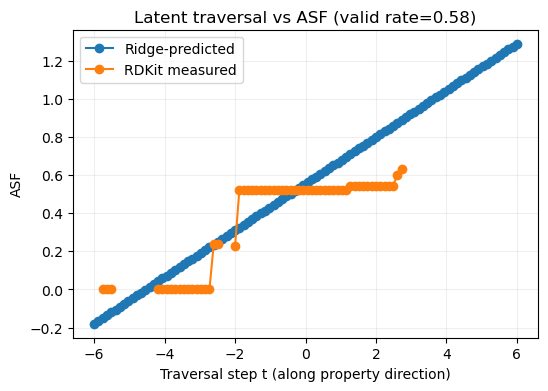

/opt/anaconda3/envs/ltvae/lib/python3.11/site-packages/rdkit/Chem/Draw/IPythonConsole.py:261: UserWarning: Truncating the list of molecules to be displayed to 50. Change the maxMols value to display more.
  warnings.warn(


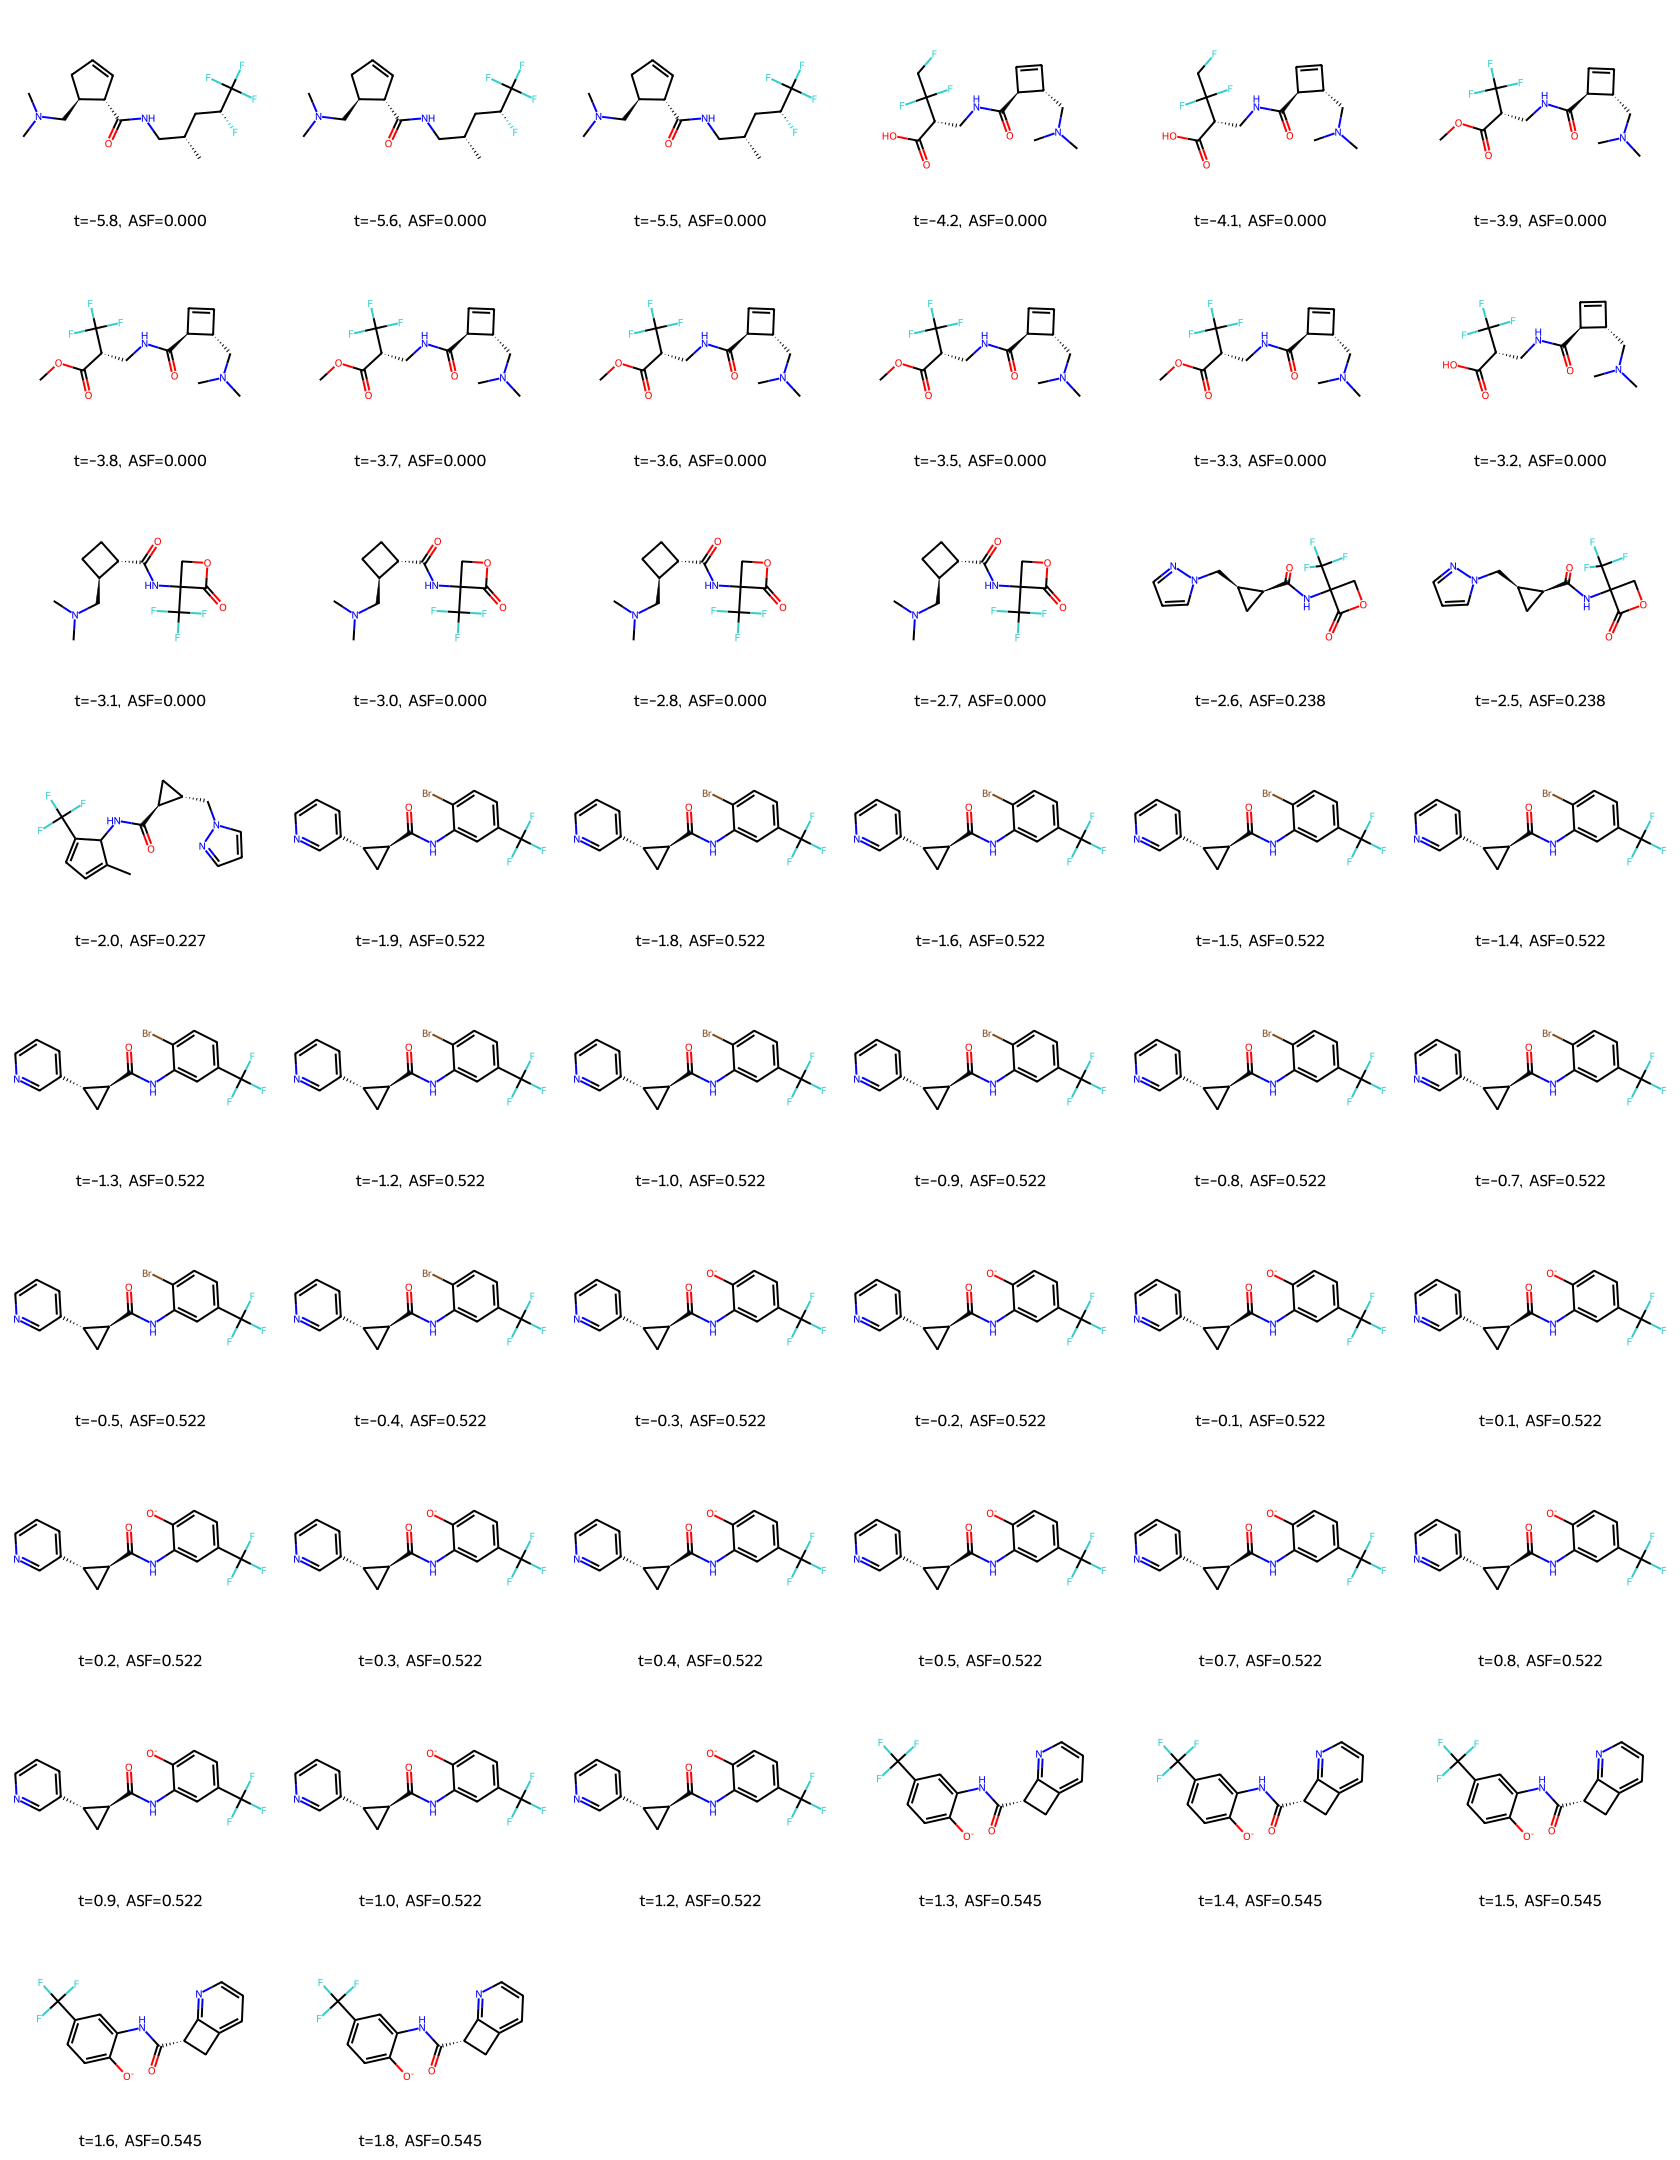

Anchor SMILES: Cc1ccccc1-n1nc(C(=O)N(C)[C@@H](C)CC#N)c2c1CCC2
Anchor MW = 322.412
Decoded SMILES (first 5): ['Cc1ccccc1-n1nc(C(=O)N(C)CC)c[nH+]1CC', 'Cc1ccccc1-n1nc(C(=O)N(C)CC)c[nH+]1CC', 'Cc1ccccc1-n1nc(C(=O)N(C)CC)c[nH+]1CC', 'Cc1ccccc1-n1nc(C(=O)N(C)CC)c[nH+]1CC', 'Cc1ccccc1-n1nc(C(=O)N(C)CC)c[nH+]1CC']


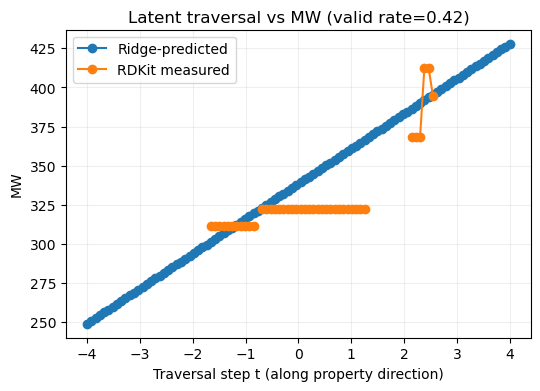

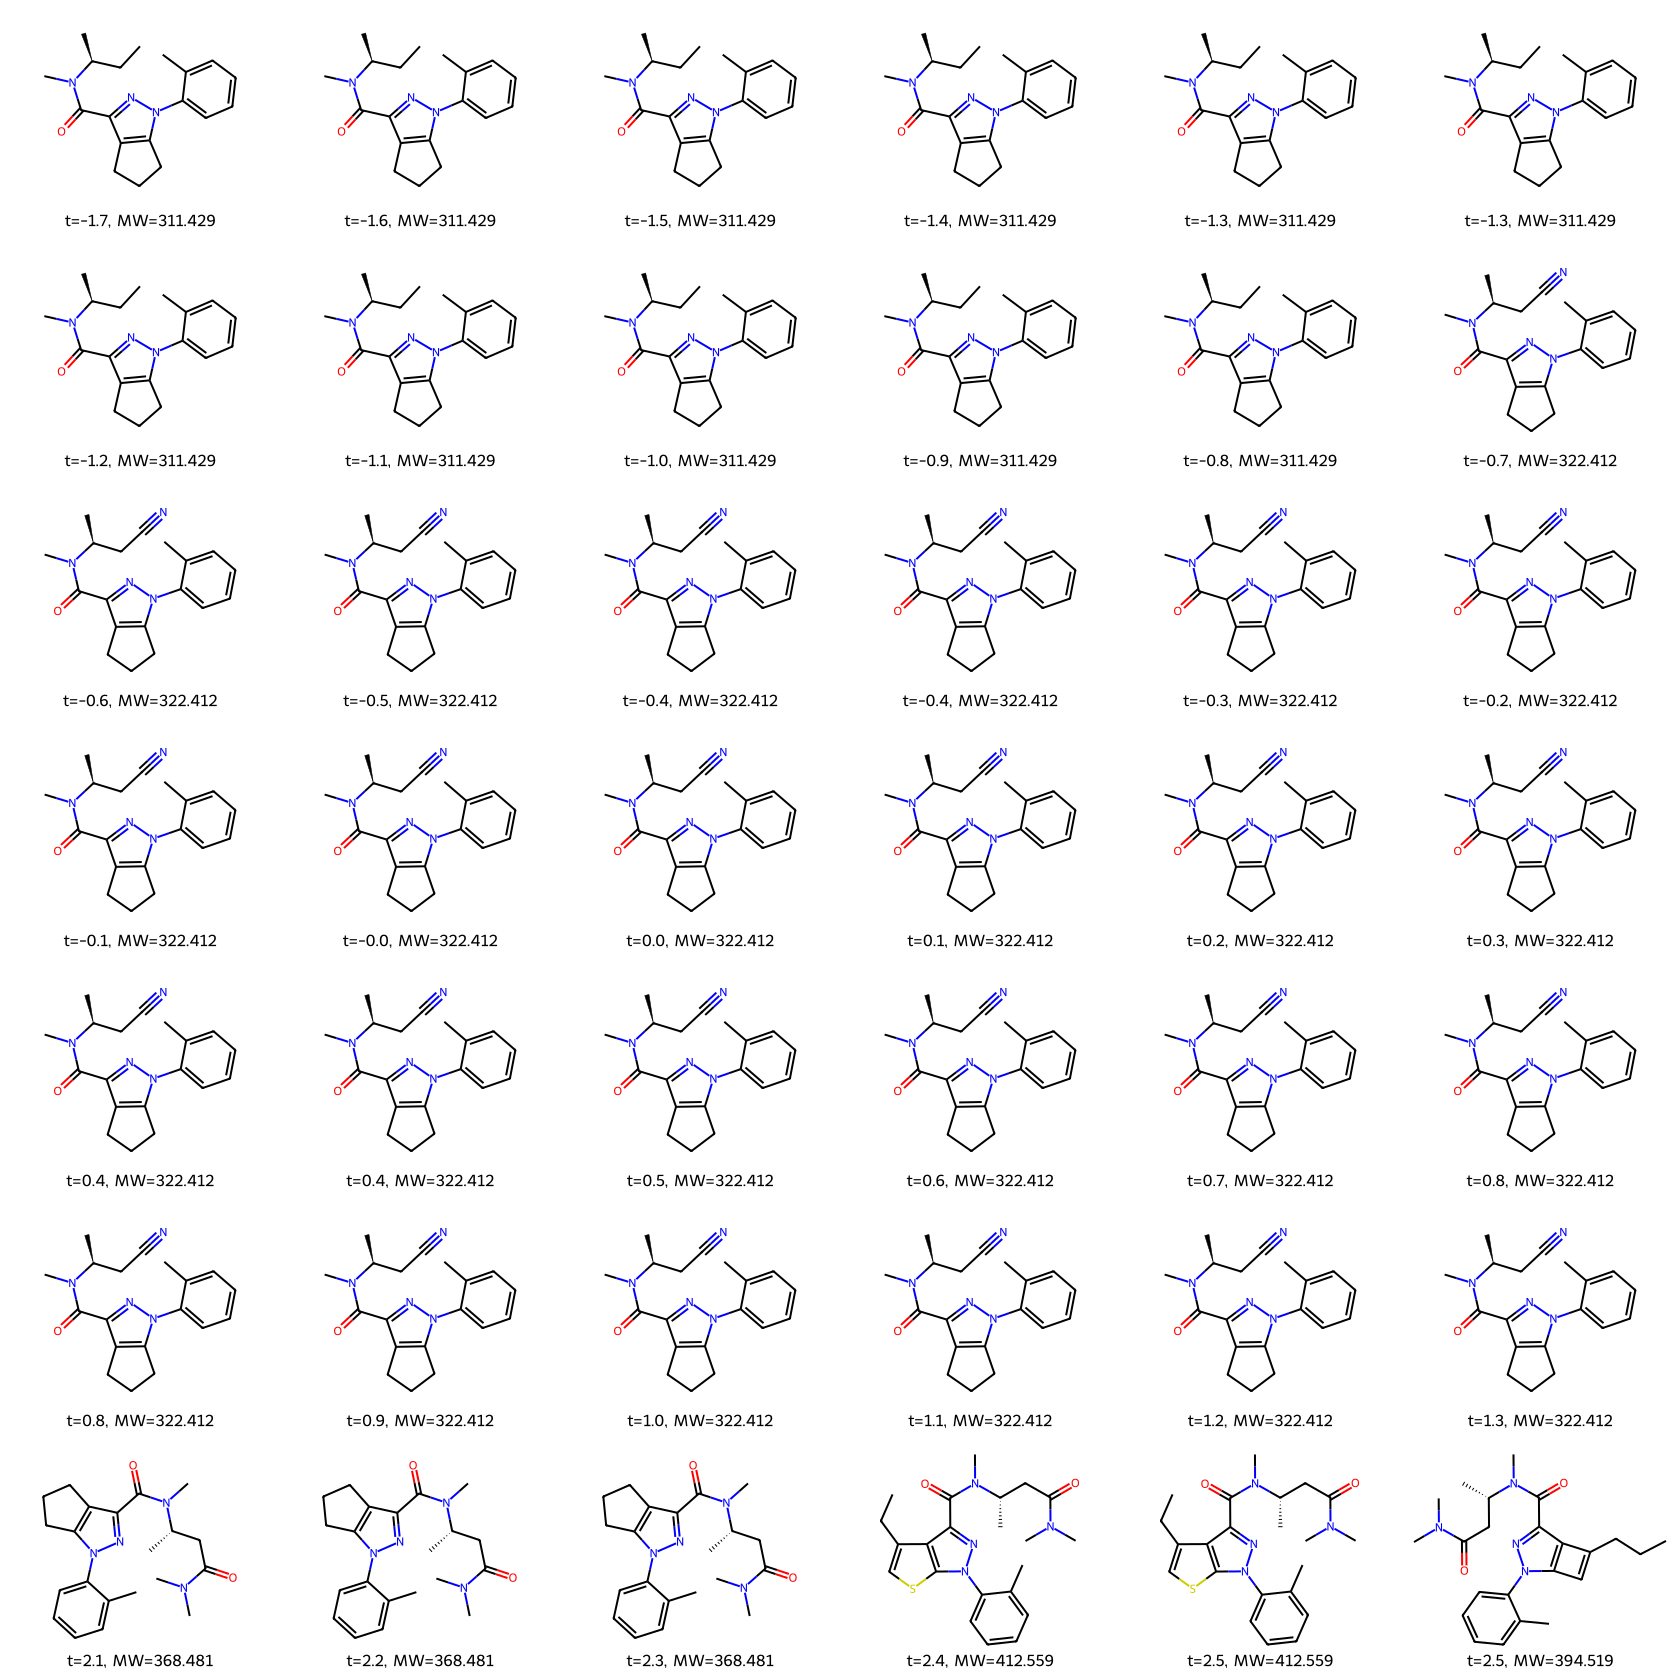

In [16]:
aromsurffrac_traversal = run_latent_traversal("AromSurfFrac")
aromsurffrac_molecules = draw_traversal_samples(aromsurffrac_traversal, "AromSurfFrac")
display(aromsurffrac_molecules)

mw_traversal = run_latent_traversal("MW", ts=np.linspace(-4.0, 4.0, 100))
mw_molecules = draw_traversal_samples(mw_traversal, "MW")
display(mw_molecules)
